# 03 - Analiza grešaka

Pokrenuti **nakon** treniranja (na Kaggle-u, ili lokalno ako su checkpoint-i preuzeti).
Generiše kvalitativne dokaze za rad:

1. Confusion matrice (flat sa 38 klasa; vrsta L1; head za bolesti po vrsti).
2. Most-confused parovi klasa.
3. Tabela per-class F1 (gde nebalansiranost najviše utiče).
4. **Grad-CAM** na pogrešno klasifikovanim slikama - dokaz o background bias-u.
5. Sažetak error propagation-a za hijerarhiju.

Politika metrika: macro F1 je primarna; accuracy se prikazuje samo kao sekundarna metrika uz napomenu.

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loaders import build_dataset, build_loader
from src.data.splits import LabelMaps
from src.evaluation.metrics import compute_metrics, confusion, per_class_table
from src.evaluation.error_analysis import (
    plot_confusion_matrix, most_confused_pairs, find_misclassified, gradcam_overlay,
)
from src.models.factory import build_model
from src.utils.config import load_config
from src.utils.seed import seed_everything

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'plantvillage dataset' / 'color'
SPLITS_DIR = PROJECT_ROOT / 'data' / 'splits'
maps = LabelMaps.from_json(SPLITS_DIR / 'label_maps.json')

C:\Users\Marija\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Učitavanje istreniranog flat modela

Usmeriti `EXP` na direktorijum eksperimenta koji je zapisao `train_flat.py`.

In [2]:
cfg = load_config(PROJECT_ROOT / 'configs' / 'resnet50_flat.yaml')
EXP = PROJECT_ROOT / 'experiments' / cfg.experiment.name
model = build_model(dict(cfg.model.to_dict()), cfg.task.num_classes)
ckpt = torch.load(EXP / 'best.pth', map_location=device)
model.load_state_dict(ckpt['model_state']); model.to(device).eval()
print('loaded', EXP / 'best.pth', '| best', ckpt.get('monitor'), '=', round(ckpt.get('score', 0), 4))

loaded <repo>\experiments\resnet50_flat\best.pth | best macro_f1 = 0.9882


## Prikupljanje test predictions

In [3]:
test_ds = build_dataset(data_root=DATA_ROOT, splits_dir=SPLITS_DIR, split='test',
                        mode='flat', img_size=cfg.data.img_size)
loader = build_loader(test_ds, batch_size=64, is_train=False, num_workers=2)

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in loader:
        logits = model(x.to(device))
        y_true.append(y.numpy()); y_pred.append(logits.argmax(1).cpu().numpy())
y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred)

res = compute_metrics(y_true, y_pred, num_classes=maps.num_classes)
print('macro F1 :', round(res.macro_f1, 4), '(primary)')
print('weighted :', round(res.weighted_f1, 4))
print('bal acc  :', round(res.balanced_accuracy, 4))
print('accuracy :', round(res.accuracy, 4), '(secondary; over-credits majority classes)')

C:\Users\Marija\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


macro F1 : 0.9843 (primary)
weighted : 0.9868
bal acc  : 0.9859
accuracy : 0.9867 (secondary; over-credits majority classes)


## Confusion matrix (38 klasa) + most-confused parovi

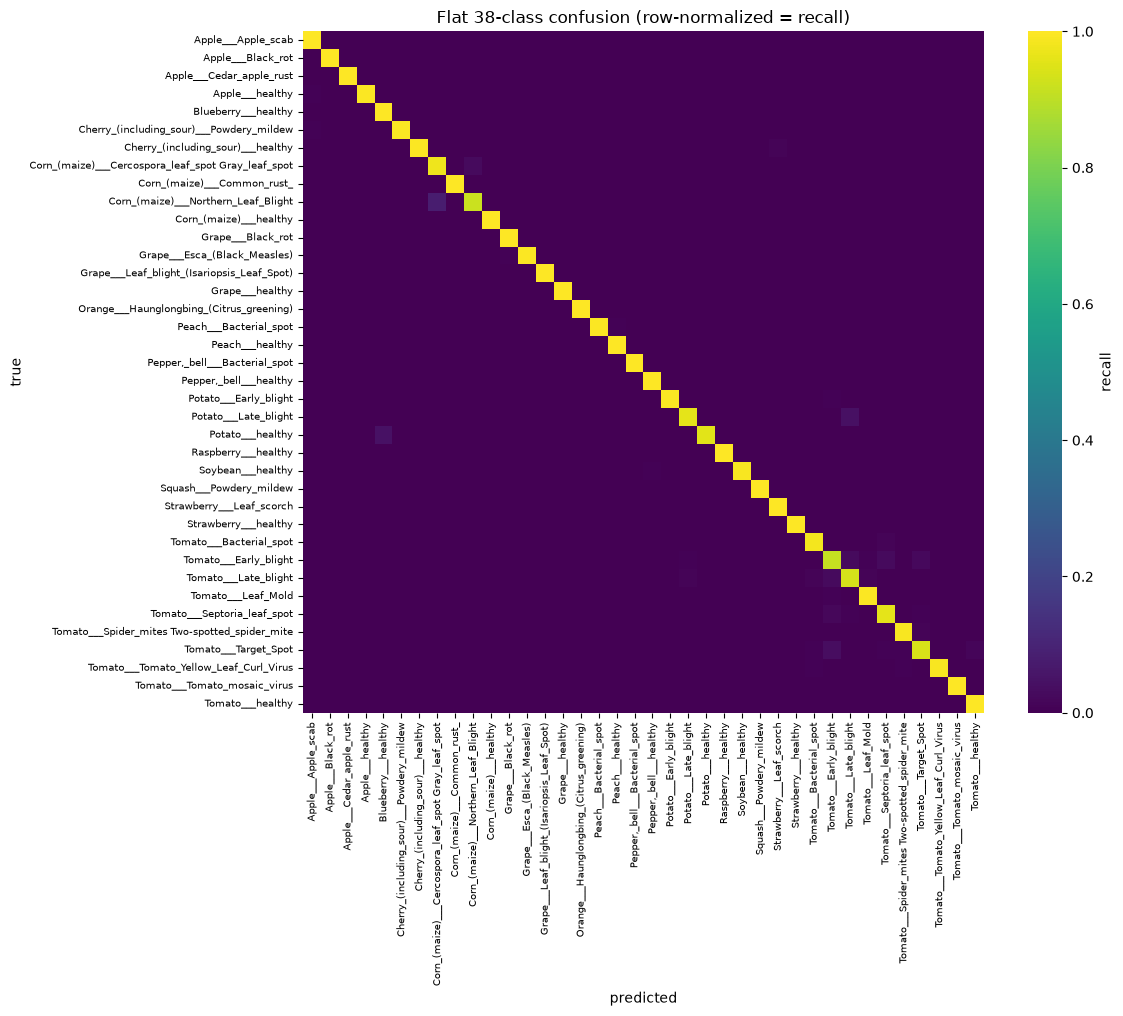

,true,predicted,count
0,Corn_(maize)___Northern_Leaf_Blight,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,12
1,Tomato___Late_blight,Tomato___Early_blight,7
2,Tomato___Target_Spot,Tomato___Early_blight,7
3,Potato___Late_blight,Tomato___Late_blight,6
4,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato___Spider_mites Two-spotted_spider_mite,5
5,Tomato___Septoria_leaf_spot,Tomato___Early_blight,5
6,Tomato___Early_blight,Tomato___Late_blight,4
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato___Bacterial_spot,4
8,Tomato___Early_blight,Tomato___Septoria_leaf_spot,4
9,Tomato___Bacterial_spot,Tomato___Septoria_leaf_spot,3


In [4]:
names = [maps.id_to_class[i] for i in range(maps.num_classes)]
cm = confusion(y_true, y_pred, num_classes=maps.num_classes)
plot_confusion_matrix(cm, names, normalize=True,
                      title='Flat 38-class confusion (row-normalized = recall)')
plt.show()
most_confused_pairs(cm, names, top_k=15)

## Per-class F1 (najlošije klase prve)

In [5]:
per_class_table(res, names).head(15)

,class,precision,recall,f1,support
0,Tomato___Early_blight,0.867089,0.913333,0.889610,150
1,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.862069,0.974026,0.914634,77
2,Tomato___Late_blight,0.953737,0.933798,0.943662,287
3,Tomato___Target_Spot,0.956522,0.938389,0.947368,211
4,Corn_(maize)___Northern_Leaf_Blight,0.985401,0.918367,0.950704,147
5,Tomato___Septoria_leaf_spot,0.969466,0.958491,0.963947,265
6,Potato___Late_blight,0.972973,0.960000,0.966443,150
7,Tomato___Bacterial_spot,0.972050,0.981191,0.976599,319
8,Potato___healthy,1.000000,0.956522,0.977778,23
9,Peach___healthy,0.964286,1.000000,0.981818,54


## Grad-CAM na pogrešno klasifikovanim primerima (provera background bias-a)

Ako se heatmapa koncentriše na uniformnu pozadinu umesto na leziju na listu,
model koristi prečicu (shortcut) iz dataset-a. Ovo je ključna slika koja prikazuje ograničenje.

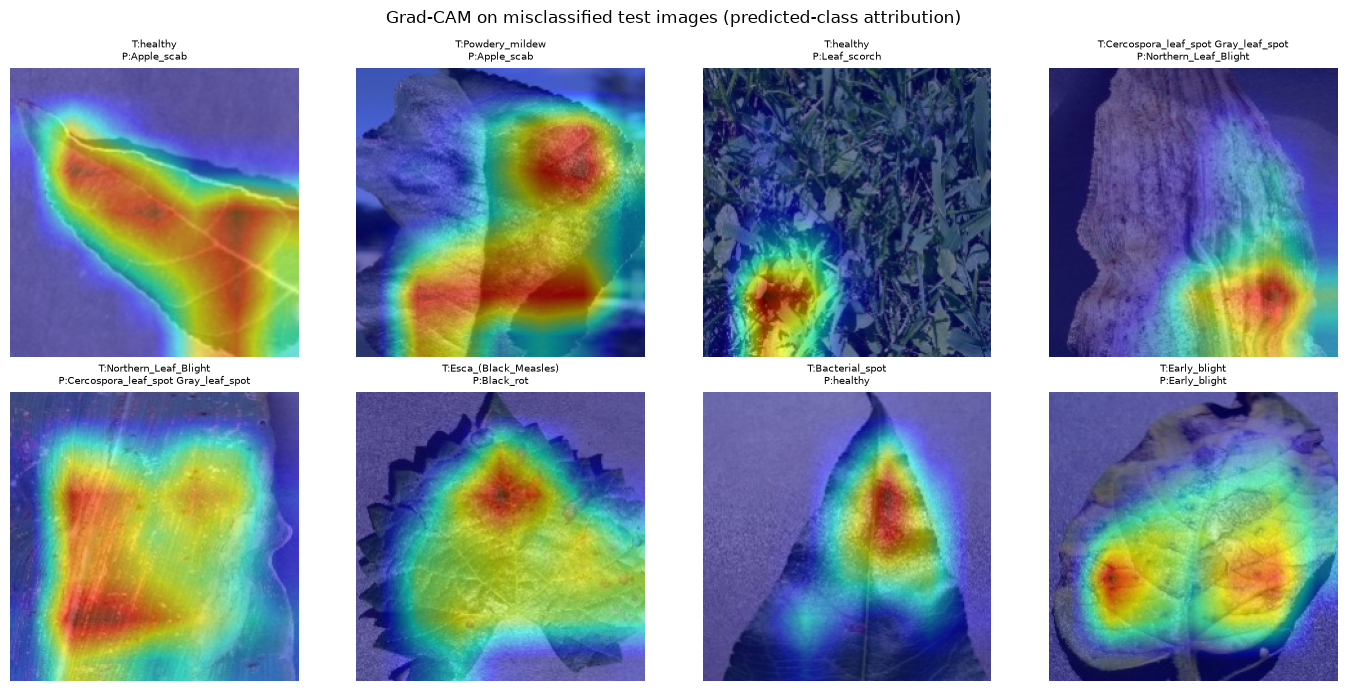

In [6]:
wrong = find_misclassified(y_true, y_pred, max_per_pair=1)[:8]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, idx in zip(axes.ravel(), wrong):
    img, true_label = test_ds[idx]
    overlay, _ = gradcam_overlay(model, img, target_class=int(y_pred[idx]))
    ax.imshow(overlay); ax.axis('off')
    ax.set_title(f"T:{maps.id_to_class[true_label].split('___')[-1]}\n"
                 f"P:{maps.id_to_class[int(y_pred[idx])].split('___')[-1]}", fontsize=7)
fig.suptitle('Grad-CAM on misclassified test images (predicted-class attribution)')
plt.tight_layout(); plt.show()

## Hijerarhijski error propagation (opciono)

Zahteva istreniranu hijerarhiju; videti `scripts/evaluate_pipeline.py` za potpuno pokretanje.
Sažetak (dict) koji se zapisuje (`test_metrics.json`) sadrži
`share_of_errors_due_to_species` - glavni broj za error propagation.

In [7]:
import json
hier_metrics = PROJECT_ROOT / 'experiments' / 'resnet50_hierarchical' / 'test_metrics.json'
if hier_metrics.exists():
    print(json.dumps(json.loads(hier_metrics.read_text()), indent=2))
else:
    print('Run scripts/evaluate_pipeline.py first to produce', hier_metrics)

{
  "hierarchical": {
    "end_to_end_macro_f1": 0.9740681074359758,
    "end_to_end_weighted_f1": 0.9820633120763492,
    "end_to_end_balanced_acc": 0.9813328700220223,
    "end_to_end_accuracy": 0.9819543334151731,
    "species_macro_f1": 0.9960212216579762,
    "disease_given_correct_species_macro_f1": 0.9815404683314046,
    "species_correct_frac": 0.9961944512644243,
    "end_to_end_correct_frac": 0.9819543334151731,
    "errors_from_species": 31,
    "errors_from_disease_only": 116,
    "share_of_errors_due_to_species": 0.2108843537414966
  },
  "flat": {
    "macro_f1": 0.984255470635476,
    "weighted_f1": 0.9867877416109809,
    "balanced_accuracy": 0.9859107272697374,
    "accuracy": 0.9867419592438006
  }
}
